# Indian Startup Funding Analysis (2015–2020)

**Goal:** understand where Indian startup funding went between 2015 and early 2020 — which cities, industries, investment stages, startups and investors dominate, and how funding moved over time.

**Dataset:** `data/startup_funding.csv` — 3,044 funding-round records (date, startup, industry, city, investors, round type, amount in USD).

**Workflow:** 1) Load & inspect → 2) Clean → 3) Explore (10 charts) → 4) Findings & limitations

In [1]:
import re
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 13})

Path("images").mkdir(exist_ok=True)

def usd_fmt(x, _):
    if x >= 1e9: return f"${x/1e9:.1f}B"
    if x >= 1e8: return f"${x/1e6:.0f}M"
    if x >= 1e6: return f"${x/1e6:.1f}M"
    if x >= 1e3: return f"${x/1e3:.0f}K"
    return f"${x:.0f}"
usd_axis = FuncFormatter(usd_fmt)

def save(name):
    plt.tight_layout()
    plt.savefig(f"images/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

def label_bars(ax, values, fontsize=9):
    """Put a $ label above each bar."""
    ax.bar_label(ax.containers[0], labels=[usd_fmt(v, 0) for v in values], padding=3, fontsize=fontsize)
    ax.margins(y=0.12)


## 1. Load & inspect

In [2]:
raw = pd.read_csv("data/startup_funding.csv", encoding="utf-8-sig")
raw.columns = ["sr_no","date","startup_name","industry_vertical","subvertical",
               "city","investors_name","investment_type","amount_usd","remarks"]
print("Raw shape:", raw.shape)
raw.head()

Raw shape: (3044, 10)


,sr_no,date,startup_name,industry_vertical,subvertical,city,investors_name,investment_type,amount_usd,remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [3]:
pd.DataFrame({"missing": raw.isna().sum(), "missing_%": (raw.isna().mean()*100).round(1)})

,missing,missing_%
sr_no,0,0.0
date,0,0.0
startup_name,0,0.0
industry_vertical,171,5.6
subvertical,936,30.7
city,180,5.9
investors_name,24,0.8
investment_type,4,0.1
amount_usd,960,31.5
remarks,2625,86.2


**Problems found in the raw data** (each is handled below):
- Hidden junk characters in text (`\\xc2\\xa0`, `\\n`) split the same value into several labels
- Dates are `dd/mm/yyyy`, plus a few malformed ones (`12/05.2015`, `01/07/015`)
- Amounts use Indian comma grouping (`20,00,00,000`) and contain `undisclosed` / `N/A`
- The same city, industry, investment type and startup appear under many spellings
- ~31% of rounds have no disclosed amount

## 2. Clean

In [4]:
df = raw.copy()

# 2.1 strip hidden junk characters / whitespace from text columns
def strip_junk(s):
    return (s.astype("string")
             .str.replace(r"\\+x[0-9a-fA-F]{2}", "", regex=True)
             .str.replace(r"\\+n", " ", regex=True)
             .str.replace(r"\s+", " ", regex=True)
             .str.strip())

text_cols = ["date","startup_name","industry_vertical","subvertical","city",
             "investors_name","investment_type","amount_usd"]
for c in text_cols:
    df[c] = strip_junk(df[c])

# 2.2 dates: dd/mm/yyyy (the old notebook parsed month-first, silently dropping 57% of years)
def parse_date(s):
    if pd.isna(s): return pd.NaT
    p = [x for x in re.split(r"\D+", s) if x]
    if len(p) == 2 and len(p[1]) == 6: p = [p[0], p[1][:2], p[1][2:]]   # 05/072018
    if len(p) != 3: return pd.NaT
    d, m, y = p
    if len(y) == 3: y = "2" + y                                           # 015 -> 2015
    try: return pd.Timestamp(int(y), int(m), int(d))
    except ValueError: return pd.NaT

df["date"]  = df["date"].map(parse_date)
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.month
print("Rows with unparseable date:", df["date"].isna().sum())

# 2.3 amounts: remove commas / '+', non-numeric (undisclosed, N/A) -> NaN
df["amount_usd"] = pd.to_numeric(df["amount_usd"].str.replace(r"[,+]", "", regex=True), errors="coerce")
n_disclosed = int(df["amount_usd"].notna().sum())

Rows with unparseable date: 0


In [5]:
# 2.4 standardise startups, cities, industries, investment types
df["startup_name"] = df["startup_name"].replace({
    "Ola Cabs":"Ola","Olacabs":"Ola","Flipkart.com":"Flipkart",
    "Oyo Rooms":"OYO","OYO Rooms":"OYO","Oyorooms":"OYO","Paytm Marketplace":"Paytm"})

def first_city(s):
    if pd.isna(s): return "Unknown"
    return re.split(r"\s*(?:/|,|&| and )\s*", s)[0].strip()      # "Bangalore / SFO" -> "Bangalore"

df["city"] = df["city"].map(first_city).replace({
    "Bangalore":"Bengaluru","Kormangala":"Bengaluru",
    "Gurgaon":"Gurugram","New Delhi":"Delhi","Nw Delhi":"Delhi",
    "Ahemadabad":"Ahmedabad","Ahemdabad":"Ahmedabad","Kolkatta":"Kolkata",
    "Bhubneswar":"Bhubaneswar","Andheri":"Mumbai","Chembur":"Mumbai",
    "Taramani":"Chennai","SFO":"San Francisco","USA":"US"})

df["industry_vertical"] = df["industry_vertical"].replace({
    "eCommerce":"E-Commerce","ECommerce":"E-Commerce","E-commerce":"E-Commerce","Ecommerce":"E-Commerce",
    "Ed-Tech":"Education","Edtech":"Education","FinTech":"Finance"}).fillna("Unknown")
# remaining spelling variants (exact labels only; free-text descriptions are left untouched)
for pattern, label in [(r"(?i)^e[\s\-]?commerce$", "E-Commerce"), (r"(?i)^fin[\s\-]?tech$", "Finance"), (r"(?i)^ed[\s\-]?tech$", "Education")]:
    df["industry_vertical"] = df["industry_vertical"].str.replace(pattern, label, regex=True)

def std_investment(s):
    if pd.isna(s): return "Undisclosed"
    t = s.lower().replace("-", " ")
    if "seed" in t or "angel" in t or "angle" in t: return "Seed / Angel"
    if "private" in t or t == "equity" or "equity based" in t: return "Private Equity"
    if "pre series" in t: return "Pre-Series A"
    m = re.match(r"series ([a-j])", t)
    if m: return "Series " + m.group(1).upper()
    if "debt" in t or "loan" in t: return "Debt"
    if "crowd" in t: return "Crowd Funding"
    return "Other"

df["investment_type"] = df["investment_type"].map(std_investment)
df["investors_name"]  = df["investors_name"].fillna("Undisclosed")
print("Unique cities:", df["city"].nunique(), "| investment types:", df["investment_type"].nunique())

Unique cities: 64 | investment types: 16


In [6]:
# 2.5 keep rounds with a disclosed amount, drop exact duplicates
df = df.dropna(subset=["amount_usd"])
df = df.drop_duplicates(subset=[c for c in df.columns if c != "sr_no"])

# 2.6 one clear data-entry outlier: 'Rapido Bike Taxi' Series B = $3.9B (3,90,00,00,000).
# That would make a bike-taxi startup the 2nd most funded company in India, so it is excluded.
bad = df["startup_name"].eq("Rapido Bike Taxi") & df["amount_usd"].gt(3e9)
print("Excluded suspicious rows:", int(bad.sum()))
df = df[~bad].reset_index(drop=True)

summary = pd.Series({
    "Raw rows": len(raw),
    "Rows with disclosed amount": n_disclosed,
    "Final rows used in analysis": len(df),
    "Rows with a valid year": int(df["year"].notna().sum()),
    "Total funding analysed (USD)": f"${df['amount_usd'].sum()/1e9:.1f}B",
    "Date range": f"{df['date'].min():%d %b %Y} to {df['date'].max():%d %b %Y}",
})
summary

Excluded suspicious rows: 1


Raw rows                                              3044
Rows with disclosed amount                            2073
Final rows used in analysis                           2072
Rows with a valid year                                2072
Total funding analysed (USD)                        $34.2B
Date range                      02 Jan 2015 to 13 Jan 2020
dtype: object

In [7]:
df.to_csv("data/cleaned_startup_funding.csv", index=False)
total = df["amount_usd"].sum()

## 3. Executive summary
The whole story in five numbers. All figures use **disclosed** funding only (rounds with a stated amount).

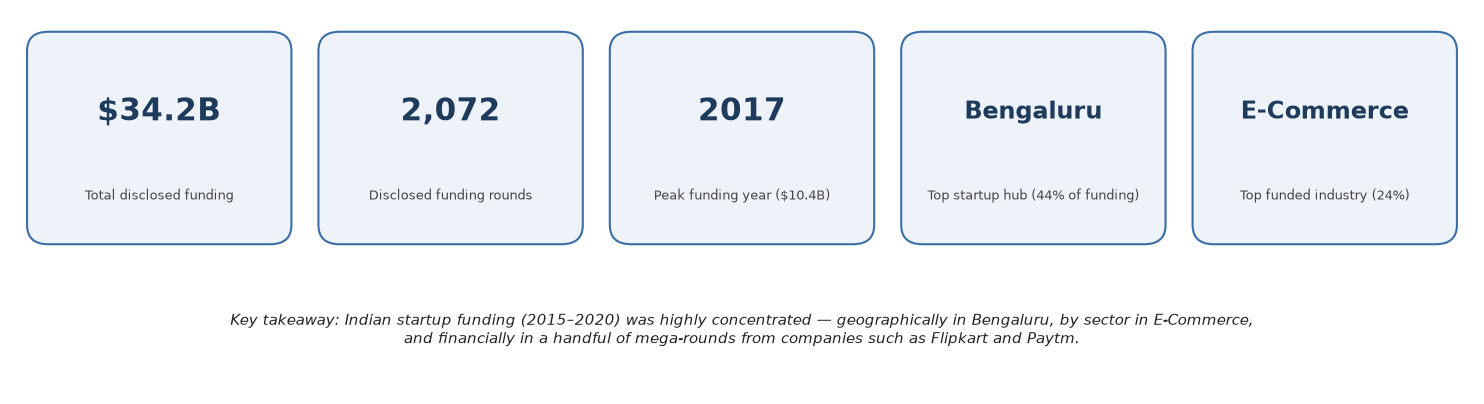

In [8]:
from matplotlib.patches import FancyBboxPatch

known_city = df[df["city"] != "Unknown"].groupby("city")["amount_usd"].sum()
known_ind  = df[df["industry_vertical"] != "Unknown"].groupby("industry_vertical")["amount_usd"].sum()
by_year    = df.groupby("year")["amount_usd"].sum()

kpis = [
    (usd_fmt(total, 0),                    "Total disclosed funding"),
    (f"{len(df):,}",                       "Disclosed funding rounds"),
    (str(int(by_year.idxmax())),           f"Peak funding year ({usd_fmt(by_year.max(), 0)})"),
    (known_city.idxmax(),                  f"Top startup hub ({known_city.max()/total:.0%} of funding)"),
    (known_ind.idxmax(),                   f"Top funded industry ({known_ind.max()/total:.0%})"),
]

fig, ax = plt.subplots(figsize=(15, 4.2))
ax.set_xlim(-1.5, 101.5); ax.set_ylim(0, 30); ax.axis("off")
w, gap = 18, 2.5
for k, (value, label) in enumerate(kpis):
    x = k * (w + gap)
    ax.add_patch(FancyBboxPatch((x, 12), w, 16, boxstyle="round,pad=0.3,rounding_size=1.5", fc="#eef3fa", ec="#3b6ea5", lw=1.5))
    ax.text(x + w/2, 22, value, ha="center", va="center", fontsize=22 if len(value) < 9 else 17, fontweight="bold", color="#1f3b5c")
    ax.text(x + w/2, 15.5, label, ha="center", va="center", fontsize=9.5, color="#444", wrap=True)
ax.text(50, 5, "Key takeaway: Indian startup funding (2015\u20132020) was highly concentrated \u2014 geographically in Bengaluru, by sector in E-Commerce,\n"
        "and financially in a handful of mega-rounds from companies such as Flipkart and Paytm.",
        ha="center", va="center", fontsize=11, style="italic", color="#222")
save("executive_summary")


> **Key takeaway:** Indian startup funding from 2015–2020 was highly concentrated geographically, financially and among a small number of startups — with **Bengaluru**, **E-Commerce**, and mega-rounds from companies such as **Flipkart** and **Paytm** dominating the ecosystem.

## 4. Exploratory analysis

### 4.1 How big is a typical round?

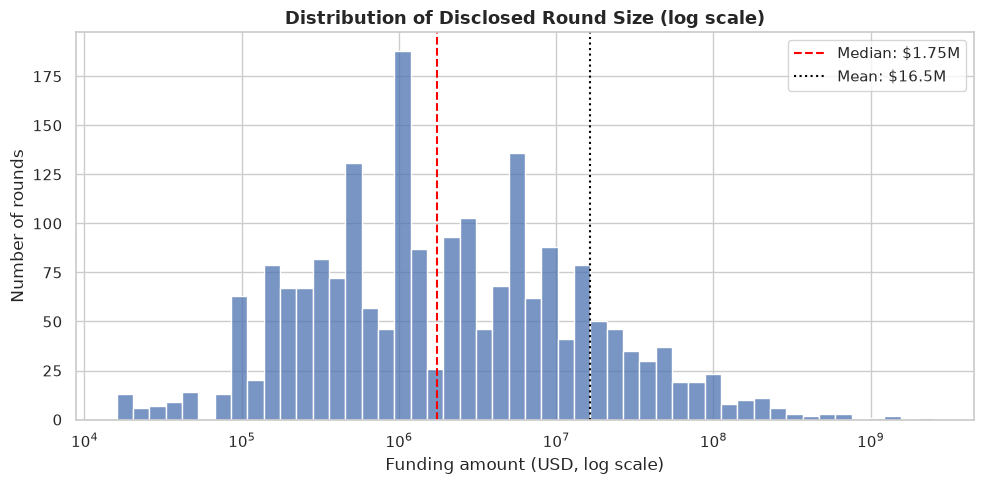

Top 10 rounds = 29% of all funding


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["amount_usd"], bins=50, log_scale=True, ax=ax)
ax.axvline(df["amount_usd"].median(), color="red", ls="--", label=f"Median: ${df['amount_usd'].median()/1e6:.2f}M")
ax.axvline(df["amount_usd"].mean(), color="black", ls=":", label=f"Mean: ${df['amount_usd'].mean()/1e6:.1f}M")
ax.set(title="Distribution of Disclosed Round Size (log scale)", xlabel="Funding amount (USD, log scale)", ylabel="Number of rounds")
ax.legend()
save("funding_distribution")
print("Top 10 rounds = %.0f%% of all funding" % (df['amount_usd'].nlargest(10).sum()/total*100))

**Insight:** Funding is extremely right-skewed. The median round is only **$1.75M** while the mean is **$16.5M**; the 10 largest rounds alone account for **~29%** of all capital. Averages are therefore misleading, so medians and totals are used throughout.

### 4.2 Geography

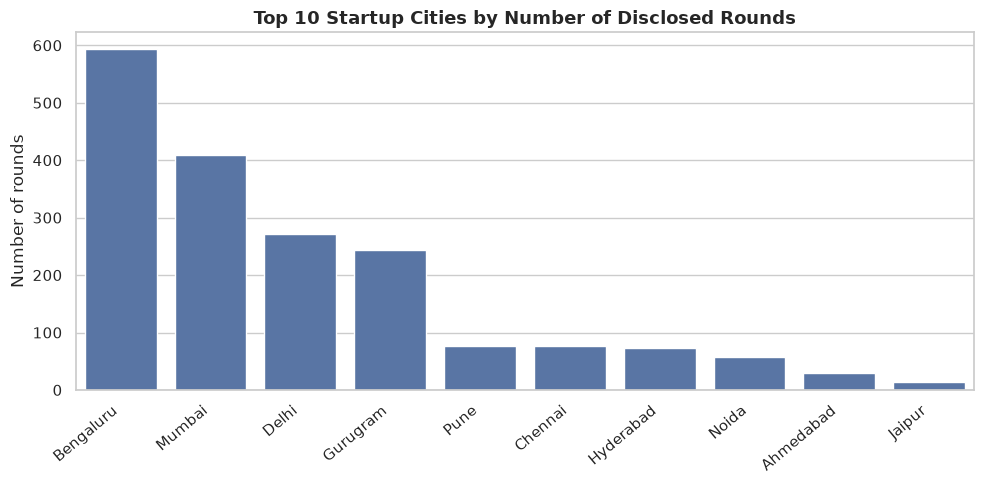

In [10]:
top_cities = df.loc[df["city"] != "Unknown", "city"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_cities.index, y=top_cities.values, ax=ax)
ax.set(title="Top 10 Startup Cities by Number of Disclosed Rounds", xlabel="", ylabel="Number of rounds")
ax.tick_params(axis="x", rotation=40)
for lbl in ax.get_xticklabels(): lbl.set_ha("right")
save("top_cities")

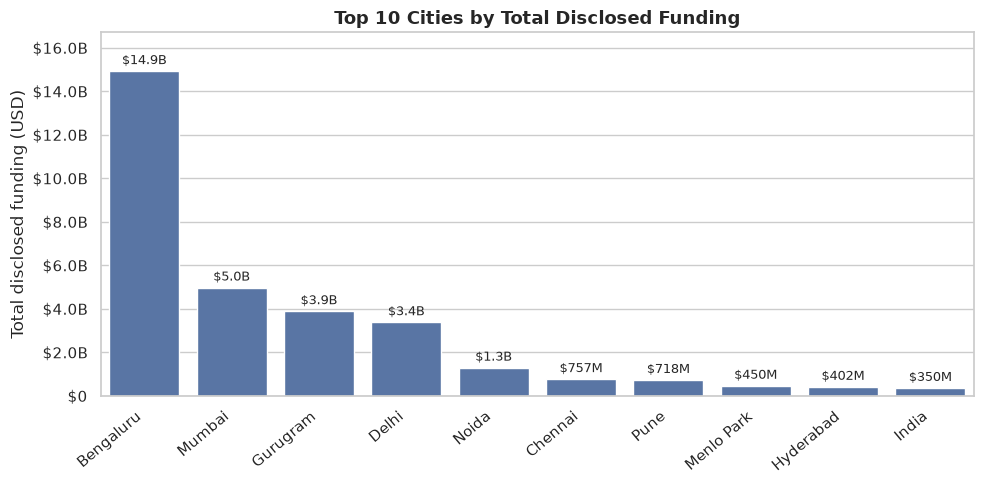

city
Bengaluru    43.6% of all funding
Mumbai       14.5% of all funding
Gurugram     11.3% of all funding
Delhi         9.8% of all funding
Noida         3.7% of all funding
Name: amount_usd, dtype: str


In [11]:
city_funding = df[df["city"] != "Unknown"].groupby("city")["amount_usd"].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=city_funding.index, y=city_funding.values, ax=ax)
ax.yaxis.set_major_formatter(usd_axis)
ax.set(title="Top 10 Cities by Total Disclosed Funding", xlabel="", ylabel="Total disclosed funding (USD)")
label_bars(ax, city_funding.values)
ax.tick_params(axis="x", rotation=40)
for lbl in ax.get_xticklabels(): lbl.set_ha("right")
save("funding_by_city")
print((city_funding.head(5)/total*100).round(1).astype(str) + "% of all funding")

**Insight:** Bengaluru is the clear hub — **593 rounds (29%)** and **~$14.9B, about 44% of all capital** once "Bangalore/Bengaluru" are merged (the earlier charts split them). Mumbai (~14.5%), Gurugram (~11.3%) and Delhi (~9.8%) follow; the Delhi-NCR belt (Delhi + Gurugram + Noida) together is ~25%, a strong second hub.

### 4.3 Industries

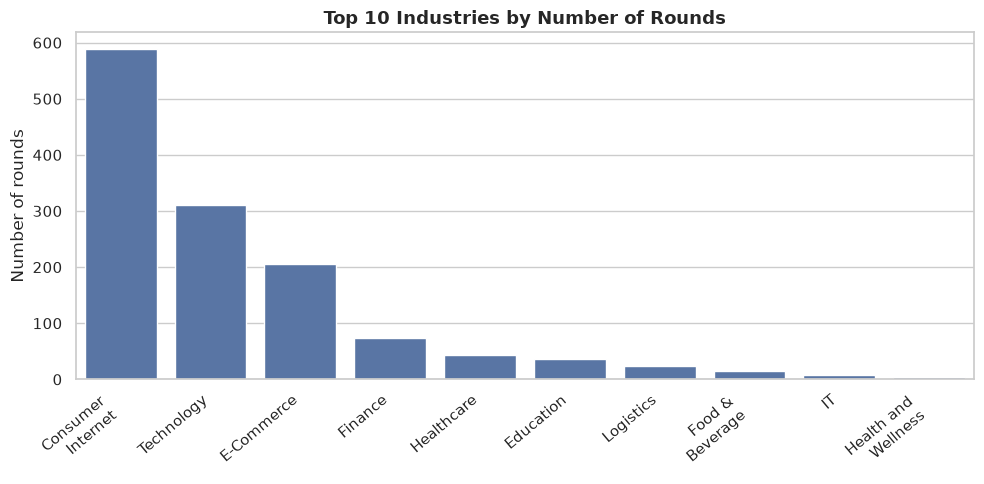

In [12]:
top_ind = df.loc[df["industry_vertical"] != "Unknown", "industry_vertical"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_ind.index, y=top_ind.values, ax=ax)
ax.set(title="Top 10 Industries by Number of Rounds", xlabel="", ylabel="Number of rounds")
ax.tick_params(axis="x", rotation=40)
ax.set_xticks(range(len(ax.get_xticklabels())))
ax.set_xticklabels([textwrap.fill(t.get_text(), 14) for t in ax.get_xticklabels()], rotation=40, ha="right")
save("top_industries")

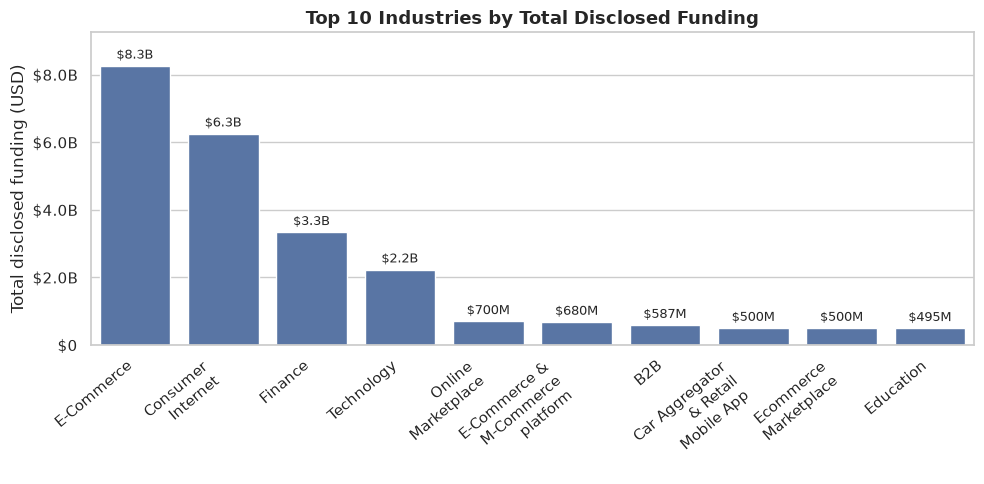

In [13]:
ind_funding = df[df["industry_vertical"] != "Unknown"].groupby("industry_vertical")["amount_usd"].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=ind_funding.index, y=ind_funding.values, ax=ax)
ax.yaxis.set_major_formatter(usd_axis)
ax.set(title="Top 10 Industries by Total Disclosed Funding", xlabel="", ylabel="Total disclosed funding (USD)")
label_bars(ax, ind_funding.values)
ax.tick_params(axis="x", rotation=40)
ax.set_xticks(range(len(ax.get_xticklabels())))
ax.set_xticklabels([textwrap.fill(t.get_text(), 14) for t in ax.get_xticklabels()], rotation=40, ha="right")
save("funding_by_industry")

**Insight:** *Consumer Internet* and *Technology* have the most deals, but **E-Commerce takes the most money (~24% of all funding)**, then Consumer Internet (~18%) and Finance (~10%). E-commerce is few, very large bets (Flipkart, Snapdeal, BigBasket); Consumer Internet is many smaller ones.

### 4.4 Startups and investors

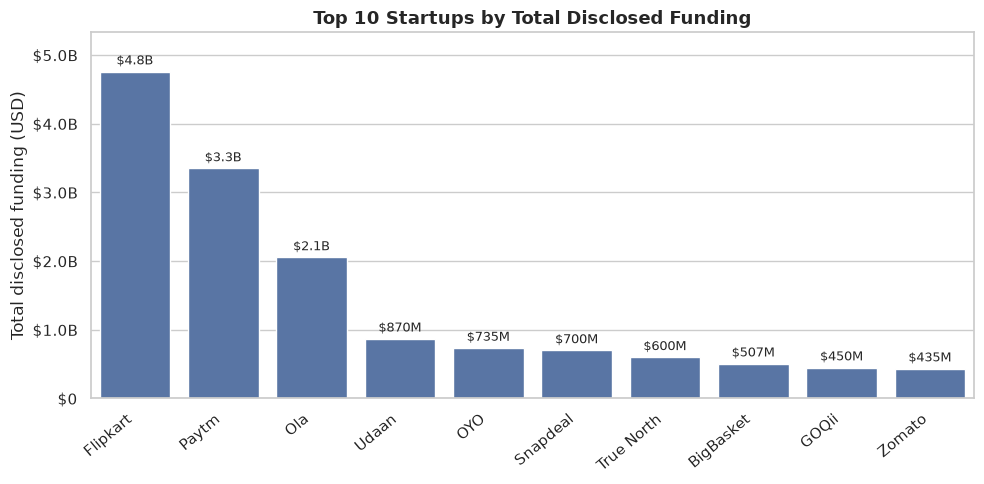

Top 10 startups = 42% of all funding


In [14]:
top_funded = df.groupby("startup_name")["amount_usd"].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_funded.index, y=top_funded.values, ax=ax)
ax.yaxis.set_major_formatter(usd_axis)
ax.set(title="Top 10 Startups by Total Disclosed Funding", xlabel="", ylabel="Total disclosed funding (USD)")
label_bars(ax, top_funded.values)
ax.tick_params(axis="x", rotation=40)
for lbl in ax.get_xticklabels(): lbl.set_ha("right")
save("top_funded_startups")
print("Top 10 startups = %.0f%% of all funding" % (top_funded.sum()/total*100))

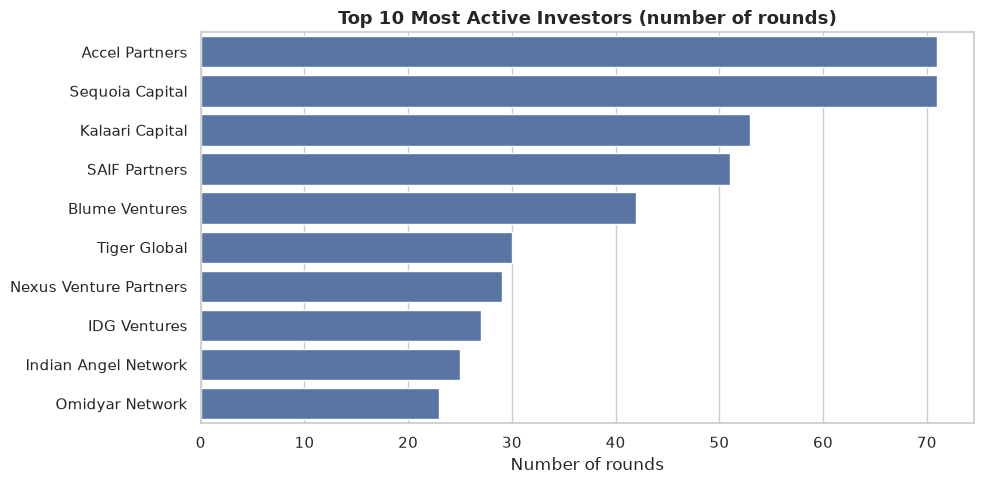

In [15]:
inv = (df.assign(investor=df["investors_name"].str.split(r",|&| and "))
         .explode("investor"))
inv["investor"] = inv["investor"].str.strip()
inv = inv[~inv["investor"].str.lower().str.contains(r"undisclosed|unknown|^others?$|^group of|^$", regex=True, na=True)]
top_inv = inv["investor"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_inv.values, y=top_inv.index, ax=ax)
ax.set(title="Top 10 Most Active Investors (number of rounds)", xlabel="Number of rounds", ylabel="")
save("top_investors")

**Insight:** Flipkart (~$4.8B), Paytm (~$3.3B) and Ola (~$2.1B) lead; the top 10 startups hold **~42%** of all capital. The most active investors by deal count are **Accel Partners and Sequoia Capital (71 rounds each)**, then Kalaari, SAIF Partners and Blume Ventures — a VC-led ecosystem concentrated in a handful of firms.

### 4.5 Investment stage

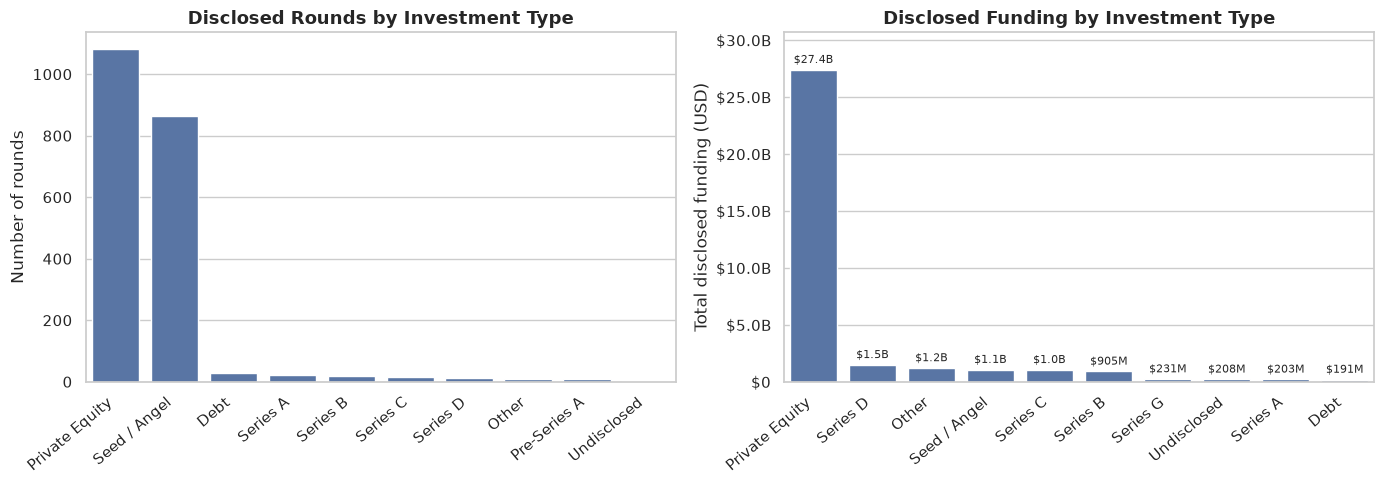

In [16]:
inv_cnt = df["investment_type"].value_counts().head(10)
inv_amt = df.groupby("investment_type")["amount_usd"].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=inv_cnt.index, y=inv_cnt.values, ax=axes[0])
axes[0].set(title="Disclosed Rounds by Investment Type", xlabel="", ylabel="Number of rounds")
sns.barplot(x=inv_amt.index, y=inv_amt.values, ax=axes[1])
axes[1].yaxis.set_major_formatter(usd_axis)
axes[1].bar_label(axes[1].containers[0], labels=[usd_fmt(v,0) for v in inv_amt.values], padding=3, fontsize=8)
axes[1].margins(y=0.12)
axes[1].set(title="Disclosed Funding by Investment Type", xlabel="", ylabel="Total disclosed funding (USD)")
for ax in axes:
    ax.tick_params(axis="x", rotation=40)
    for lbl in ax.get_xticklabels(): lbl.set_ha("right")
save("investment_types")

**Insight:** Seed/Angel (864 rounds) and Private Equity (1,082) make up ~94% of deals, but the money sits in Private Equity (**~$27.4B, ~80%**). Median size: Seed/Angel **$0.37M** vs Private Equity **$6M** vs Series D **$65M**. (Many rounds are labelled "Private Equity" without a Series A/B/C stage, so stage analysis is limited.)

### 4.6 Time trends

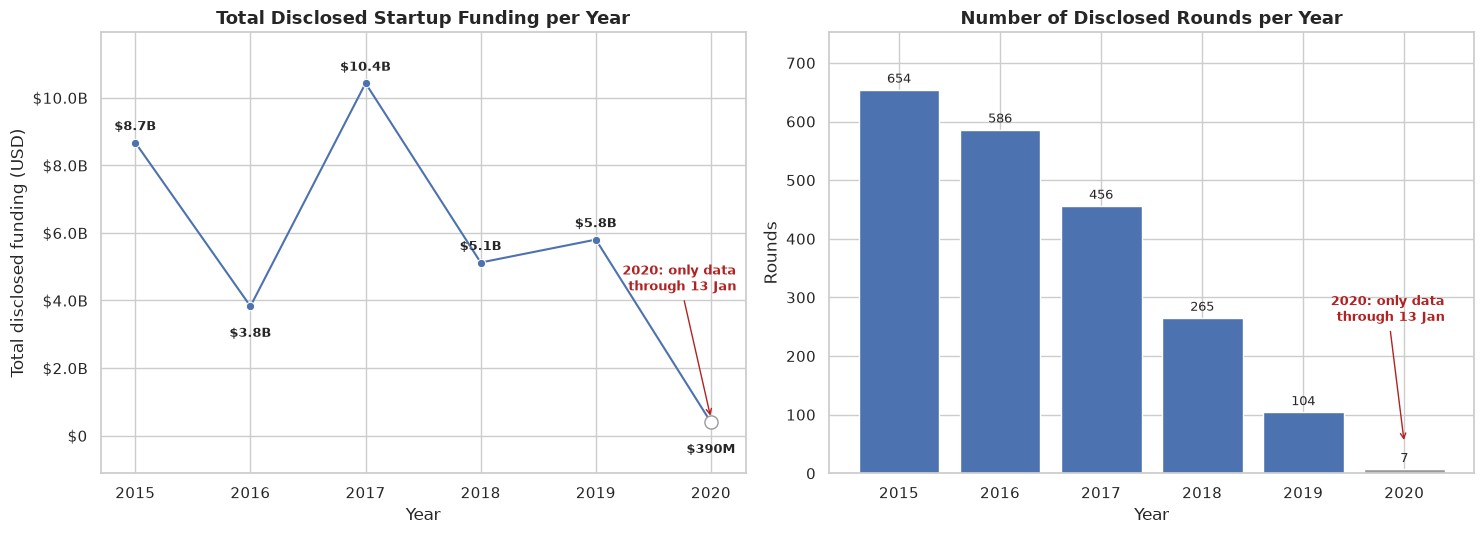

,total,rounds,median
year,,,
2015,$8.7B,654,$1.5M
2016,$3.8B,586,$1.0M
2017,$10.4B,456,$2.2M
2018,$5.1B,265,$4.0M
2019,$5.8B,104,$12.0M
2020,$390M,7,$9.0M


In [17]:
yearly = df.dropna(subset=["year"]).groupby("year").agg(total=("amount_usd","sum"), rounds=("amount_usd","size"), median=("amount_usd","median"))
yearly.index = yearly.index.astype(int)
note_2020 = "2020: only data\nthrough 13 Jan"
grey = "#9a9a9a"
note_style = dict(fontsize=9.5, color="firebrick", ha="right", fontweight="bold",
                  arrowprops=dict(arrowstyle="->", color="firebrick"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# left: total disclosed funding (line, labelled)
ax = axes[0]
sns.lineplot(x=yearly.index, y=yearly["total"], marker="o", ax=ax)
ax.scatter([2020], [yearly.loc[2020, "total"]], s=90, facecolor="white", edgecolor=grey, zorder=5)   # partial year
for yr, v in yearly["total"].items():
    dy = -22 if yr in (2016, 2020) else 9
    ax.annotate(usd_fmt(v, 0), (yr, v), textcoords="offset points", xytext=(0, dy), ha="center", fontsize=9, fontweight="bold")
ax.annotate(note_2020, xy=(2020, yearly.loc[2020, "total"] + 1.2e8), xytext=(2020.22, 4.3e9), **note_style)
ax.yaxis.set_major_formatter(usd_axis); ax.set_xticks(yearly.index); ax.set_xlim(2014.7, 2020.3); ax.margins(y=0.15)
ax.set(title="Total Disclosed Startup Funding per Year", xlabel="Year", ylabel="Total disclosed funding (USD)")

# right: number of disclosed rounds (bars, labelled, 2020 greyed)
ax = axes[1]
colors = [sns.color_palette()[0]] * (len(yearly) - 1) + [grey]
ax.bar(range(len(yearly)), yearly["rounds"], color=colors)
ax.set_xticks(range(len(yearly))); ax.set_xticklabels(yearly.index)
ax.bar_label(ax.containers[0], padding=3, fontsize=9); ax.margins(y=0.15)
ax.annotate(note_2020, xy=(len(yearly) - 1, yearly["rounds"].iloc[-1] + 45), xytext=(len(yearly) - 0.6, 260), **note_style)
ax.set(title="Number of Disclosed Rounds per Year", xlabel="Year", ylabel="Rounds")
save("yearly_funding_trend")
yearly.assign(total=yearly["total"].map(lambda v: usd_fmt(v, 0)), median=yearly["median"].map(lambda v: usd_fmt(v, 0)))


**Insight:** **2017 was the peak at ~$10.4B (30% of the period total)**, driven by Flipkart ($2.5B + $1.4B) and Paytm ($1.4B). Deal *count* fell every year (654 → 586 → 456 → 265 → 104), yet the *median* round grew from $1.5M (2015) to $12M (2019): fewer but larger, later-stage deals. 2020 holds only 7 rounds (data ends 13 Jan 2020), so it should not be read as a collapse.

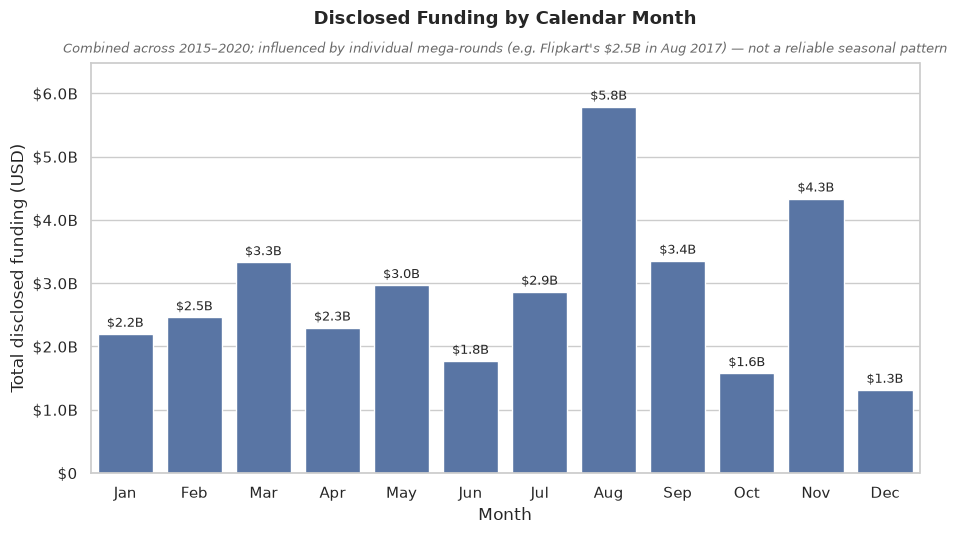

In [18]:
monthly = df.dropna(subset=["month"]).groupby("month")["amount_usd"].sum()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(x=[month_names[m-1] for m in monthly.index.astype(int)], y=monthly.values, ax=ax, color=sns.color_palette()[0])
label_bars(ax, monthly.values)
ax.yaxis.set_major_formatter(usd_axis)
ax.set_title("Disclosed Funding by Calendar Month", pad=28)
ax.text(0.5, 1.025, "Combined across 2015\u20132020; influenced by individual mega-rounds (e.g. Flipkart's $2.5B in Aug 2017) \u2014 not a reliable seasonal pattern",
        transform=ax.transAxes, ha="center", fontsize=9, style="italic", color="dimgray")
ax.set(xlabel="Month", ylabel="Total disclosed funding (USD)")
save("monthly_funding_trend")


**Insight:** August (~17%) and November (~13%) are the biggest months, but this is driven by single mega-deals (e.g., Flipkart's $2.5B in August 2017), not a reliable seasonal pattern.

## 5. Key findings

| Question | Answer |
|---|---|
| **Where?** | Bengaluru (~44%) and Delhi-NCR (~25%) |
| **Which industry?** | E-Commerce (~24%) and Consumer Internet (~18%) |
| **Who raised?** | Flipkart, Paytm, Ola |
| **Who invested?** | Accel, Sequoia, Kalaari, SAIF |
| **When?** | 2017 peak (~$10.4B) |
| **What changed?** | Fewer rounds, but much larger median round size |

1. **Bengaluru dominates** — ~44% of all funding and 29% of rounds; Delhi-NCR is a clear second hub (~25%).
2. **Funding is extremely concentrated** — top 10 rounds ≈ 29% and top 10 startups ≈ 42% of all capital; median round is just $1.75M.
3. **E-Commerce attracts the most capital (~24%)**, while Consumer Internet and Technology have the most deals.
4. **Private Equity-labelled rounds hold ~80% of the money**; Seed/Angel is ~42% of deals but only ~3% of capital.
5. **2017 was the peak (~$10.4B)**; deal counts declined every year while median round size grew ~8× (2015 → 2019).
6. **VC firms such as Accel, Sequoia, Kalaari and SAIF** are the most active investors.

## 6. Limitations
- ~31% of rounds (971) have no disclosed amount and are excluded, so every total in this notebook is **disclosed funding**, not all money invested.
- Round-type labels are inconsistent, so stage-level analysis is approximate.
- 2020 contains only 13 days of data.
- One likely data-entry error (Rapido, $3.9B) was excluded; other values were not independently verified.
- City uses the first listed location where several are given, and a few entries are not Indian cities (e.g. "India", Menlo Park).
- Industry labels are free text. Only exact spelling variants were merged (e.g. eCommerce / E-commerce / ECommerce), so related labels such as "Ecommerce Marketplace" stay separate and the E-Commerce share is conservative.

## 7. Possible next steps
Interactive dashboard (Power BI / Plotly), city-wise industry breakdown, investor co-investment network.